In [1]:
!nvidia-smi

Wed Apr 29 12:00:05 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   70C    P8             32W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
import os

base_path = "/content/drive/MyDrive/Msc Desertation/Cleft Lip and Palate & non-Cleft Lip and Palate Dataset"

cleft_path = os.path.join(base_path, "Cleft-Lip-and-Palate")
non_cleft_path = os.path.join(base_path, "Non-Cleft Image Dataset")

def count_images(folder):
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp', '.gif')
    count = 0

    for root, dirs, files in os.walk(folder):
        count += len([f for f in files if f.lower().endswith(valid_ext)])

    return count

cleft_count = count_images(cleft_path)
non_cleft_count = count_images(non_cleft_path)
total_images = cleft_count + non_cleft_count

print("Cleft Lip & Palate images:", cleft_count)
print("Non-Cleft images:", non_cleft_count)
print("Total images:", total_images)

Cleft Lip & Palate images: 168
Non-Cleft images: 247
Total images: 415


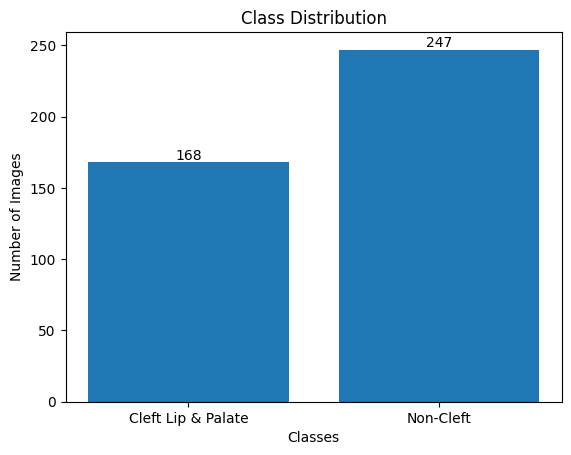

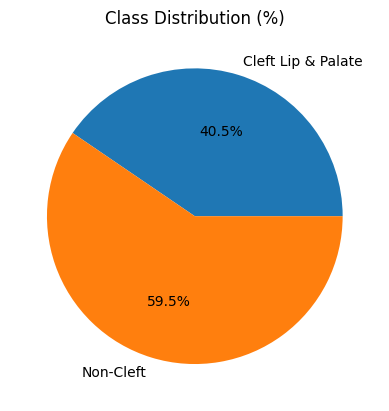

In [5]:
import matplotlib.pyplot as plt

labels = ['Cleft Lip & Palate', 'Non-Cleft']
counts = [cleft_count, non_cleft_count]

plt.figure()
plt.bar(labels, counts)

plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Number of Images")

# show values on top
for i, v in enumerate(counts):
    plt.text(i, v + 2, str(v), ha='center')

plt.show()

plt.figure()
plt.pie(counts, labels=labels, autopct='%1.1f%%')

plt.title("Class Distribution (%)")

plt.show()

In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

In [7]:
base_path = "/content/drive/MyDrive/Msc Desertation/Cleft Lip and Palate & non-Cleft Lip and Palate Dataset"

cleft_path = os.path.join(base_path, "Cleft-Lip-and-Palate")
non_cleft_path = os.path.join(base_path, "Non-Cleft Image Dataset")

def get_image_paths(folder, label):
    data = []
    valid_ext = ('.png', '.jpg', '.jpeg', '.bmp')

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(valid_ext):
                full_path = os.path.join(root, file)
                data.append((full_path, label))

    return data

cleft_data = get_image_paths(cleft_path, 0)
non_cleft_data = get_image_paths(non_cleft_path, 1)

all_data = cleft_data + non_cleft_data

print("Total images:", len(all_data))

Total images: 415


**Train / Validation / Test Split Explanation**

In this step, the dataset is divided into three parts to ensure the model is trained and evaluated properly. First, 70% of the total images are used as the training set, which is the only portion used to train the model and update its weights. The remaining 30% of the data is split equally into validation and test sets, each containing 15% of the data. The validation set is used during training to monitor the model’s performance and help tune parameters, while the test set is kept completely separate and is only used at the end to evaluate the final model performance. A stratified split is applied to maintain the same proportion of cleft and non-cleft images across all three sets, ensuring that each subset represents the overall dataset distribution accurately. This prevents biased training and unreliable evaluation results.

In [8]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    all_data, test_size=0.3, stratify=[label for _, label in all_data], random_state=42
)

val_data, test_data = train_test_split(
    temp_data, test_size=0.5, stratify=[label for _, label in temp_data], random_state=42
)

print(len(train_data), len(val_data), len(test_data))

290 62 63


**Custom Dataset Class**

In this step, a custom dataset class is created to define how images and their corresponding labels are loaded into the model. Since the dataset is stored in nested and non-standard folder structures, PyTorch cannot directly interpret it using built-in loaders. The custom dataset class solves this by storing image file paths along with their labels and defining how each image is accessed when required. During training, the model does not load all images at once; instead, it requests them one at a time. The dataset class then reads the image from disk, applies the necessary transformations, and returns the processed image along with its label. This approach ensures efficient memory usage, maintains correct label associations, and allows flexibility in handling complex dataset structures.

In [9]:
from torch.utils.data import Dataset
from PIL import Image

class CLPDataset(Dataset):
    def __init__(self, data, transform=None):
        self.data = data
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path, label = self.data[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

**Data Transformation and Augmentation**

In this step, image transformations are applied to prepare the data before feeding it into the model. For the training set, both preprocessing and data augmentation techniques are used. All images are resized to a fixed dimension to ensure consistency, and then random transformations such as horizontal flipping, slight rotation, and brightness or contrast adjustments are applied. These augmentations introduce variability in the training data, helping the model generalize better and reducing overfitting by preventing it from memorizing exact image patterns. For the validation and test sets, only basic preprocessing steps such as resizing and tensor conversion are applied, without any augmentation. This ensures that model evaluation is performed on clean and unaltered data, providing a reliable measure of real-world performance.

In [10]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor()
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

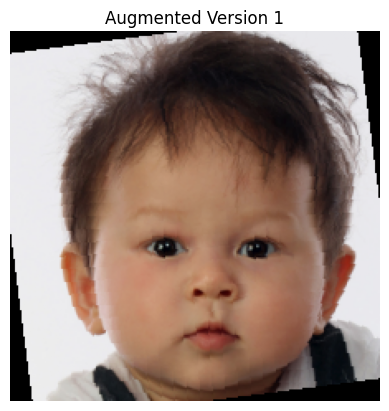

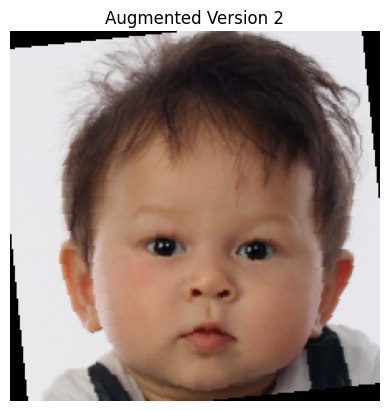

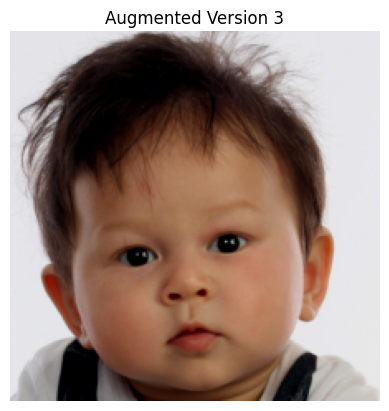

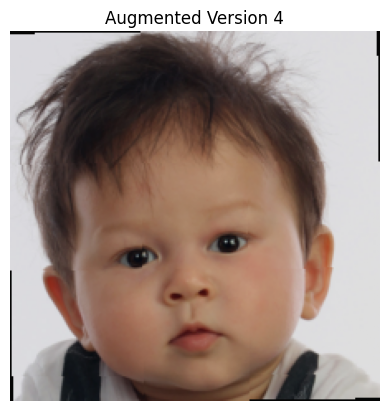

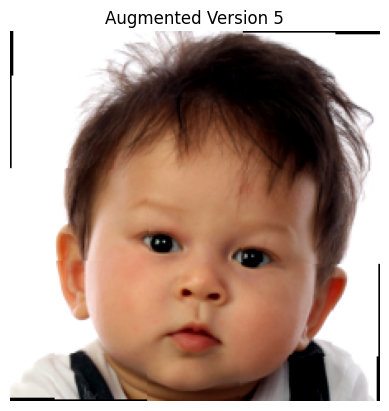

In [11]:
import matplotlib.pyplot as plt

def show_image(tensor, title=None):
    img = tensor.permute(1, 2, 0).numpy()
    plt.imshow(img)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


img_path, label = train_data[0]
image = Image.open(img_path).convert("RGB")

for i in range(5):
    transformed_image = train_transform(image)
    show_image(transformed_image, title=f"Augmented Version {i+1}")

**Creating the Dataset Objects**

In this step, the previously prepared training, validation, and test data are converted into PyTorch dataset objects using a custom dataset class. Each dataset object stores image file paths along with their corresponding labels and defines how each image should be loaded and processed. When an image is requested during training or evaluation, it is read from disk, transformed using the defined preprocessing pipeline, and then returned as a tensor along with its label. This structure allows PyTorch to efficiently access and manage the data in batches, enabling seamless integration with the training process. It ensures that the model receives properly formatted and consistently processed data during training, validation, and testing stages.

In [12]:
train_dataset = CLPDataset(train_data, transform=train_transform)
val_dataset = CLPDataset(val_data, transform=val_test_transform)
test_dataset = CLPDataset(test_data, transform=val_test_transform)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

img, label = train_dataset[0]

print("Image tensor shape:", img.shape)
print("Label:", label)

Train dataset size: 290
Validation dataset size: 62
Test dataset size: 63
Image tensor shape: torch.Size([3, 224, 224])
Label: 1


**DataLoader Explanation**

In this step, DataLoaders are created to efficiently feed data into the model during training, validation, and testing. A DataLoader takes the dataset and divides it into smaller batches, allowing the model to process multiple images at once instead of one by one. For the training set, the data is shuffled to ensure that the model does not learn any order-based patterns and improves its ability to generalize. For validation and test sets, shuffling is disabled to maintain consistent and repeatable evaluation. DataLoaders also improve performance by loading data in the background, ensuring that the GPU is continuously utilized without waiting for data to be fetched. This step is essential for efficient and stable model training.

In [13]:
from torch.utils.data import DataLoader

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [14]:
import time

# 1. Basic dataset sizes
print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))
print("-" * 50)

# 2. Inspect one batch from train loader
images, labels = next(iter(train_loader))

print("Train batch image shape:", images.shape)
print("Train batch label shape:", labels.shape)
print("Sample labels:", labels[:10])
print("-" * 50)

# 3. Class distribution check in first batch
unique, counts = labels.unique(return_counts=True)
print("Class distribution in one batch:")
for u, c in zip(unique, counts):
    print(f"Class {u.item()}: {c.item()} samples")
print("-" * 50)

# 4. Speed test (data loading sanity check)
start = time.time()
for i, (images, labels) in enumerate(train_loader):
    if i == 10:
        break
end = time.time()

print("Time for 10 batches:", round(end - start, 4), "seconds")
print("-" * 50)

# 5. Final sanity check (val batch shape)
val_images, val_labels = next(iter(val_loader))
print("Validation batch image shape:", val_images.shape)
print("Validation batch labels:", val_labels[:10])

Train batches: 10
Validation batches: 2
Test batches: 2
--------------------------------------------------
Train batch image shape: torch.Size([32, 3, 224, 224])
Train batch label shape: torch.Size([32])
Sample labels: tensor([0, 1, 1, 1, 1, 1, 0, 0, 0, 0])
--------------------------------------------------
Class distribution in one batch:
Class 0: 14 samples
Class 1: 18 samples
--------------------------------------------------
Time for 10 batches: 4.8504 seconds
--------------------------------------------------
Validation batch image shape: torch.Size([32, 3, 224, 224])
Validation batch labels: tensor([0, 1, 1, 0, 1, 0, 1, 1, 0, 1])


This code is used to verify the class distribution in the training dataset after splitting the data into train, validation, and test sets. It extracts only the labels from the train_data list, where each element contains an image path and its corresponding class label. The list comprehension removes the image paths and keeps only the labels, creating a simplified list of class identifiers. The Counter function from the collections module is then used to count how many samples belong to each class. This step is important because it ensures that the class distribution in the training set is still balanced or at least consistent with the original dataset. It helps detect any issues such as incorrect splitting, label imbalance, or data leakage before training the model.

In [15]:
from collections import Counter

labels = [label for _, label in train_data]
print(Counter(labels))

Counter({1: 173, 0: 117})


In [16]:
import torch
from collections import Counter

# train_data = [(image_path, label), ...]
labels = [label for _, label in train_data]

counts = Counter(labels)
print("Class counts:", counts)

total = sum(counts.values())

class_weights = [
    total / counts[0],  # class 0 (Cleft)
    total / counts[1]   # class 1 (Non-Cleft)
]

class_weights = torch.tensor(class_weights, dtype=torch.float)

Class counts: Counter({1: 173, 0: 117})


In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

class_weights = class_weights.to(device)
print("Class weights on device:", class_weights)

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requires_grad = True

model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

Device: cuda
Class weights on device: tensor([2.4786, 1.6763], device='cuda:0')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Epoch 1/10


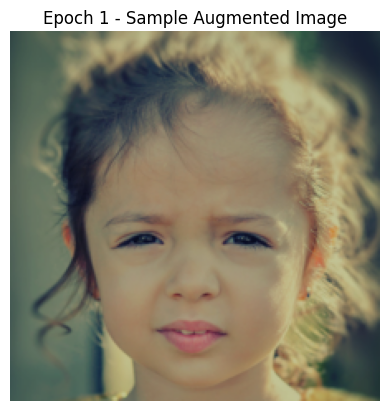

Batch 0 | Loss: 0.7763
Epoch Loss: 6.5515 | Accuracy: 66.90%

Epoch 2/10


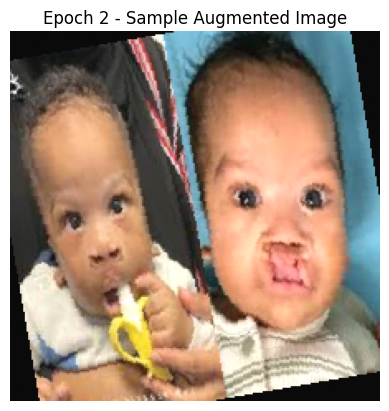

Batch 0 | Loss: 0.4731
Epoch Loss: 4.6055 | Accuracy: 85.17%

Epoch 3/10


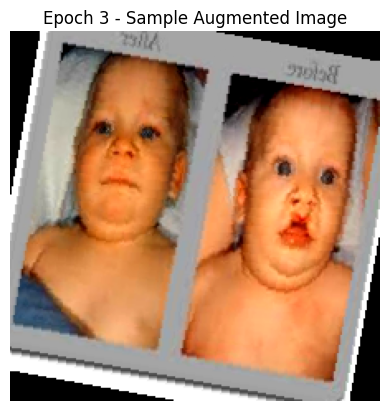

Batch 0 | Loss: 0.3654
Epoch Loss: 3.8190 | Accuracy: 89.66%

Epoch 4/10


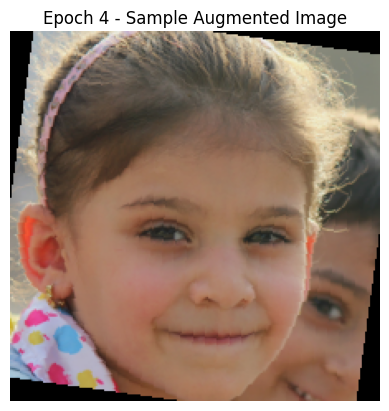

Batch 0 | Loss: 0.2896
Epoch Loss: 2.6781 | Accuracy: 94.83%

Epoch 5/10


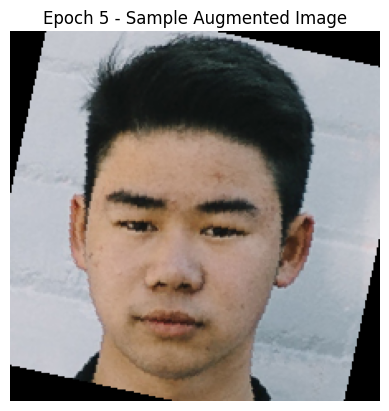

Batch 0 | Loss: 0.2235
Epoch Loss: 2.7957 | Accuracy: 95.52%

Epoch 6/10


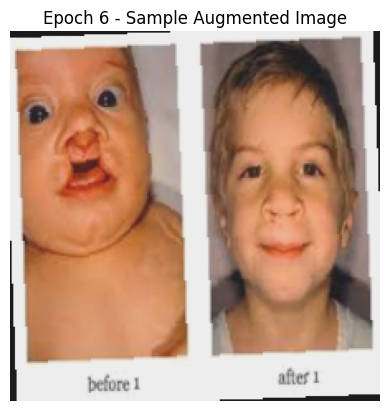

Batch 0 | Loss: 0.1803
Epoch Loss: 2.0580 | Accuracy: 96.21%

Epoch 7/10


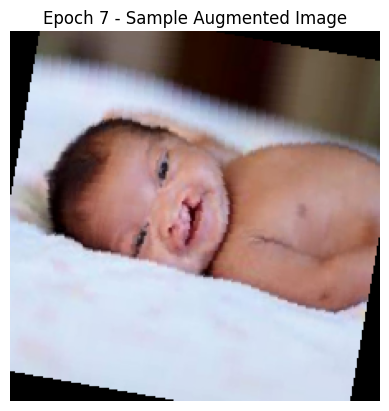

Batch 0 | Loss: 0.1569
Epoch Loss: 2.3499 | Accuracy: 96.21%

Epoch 8/10


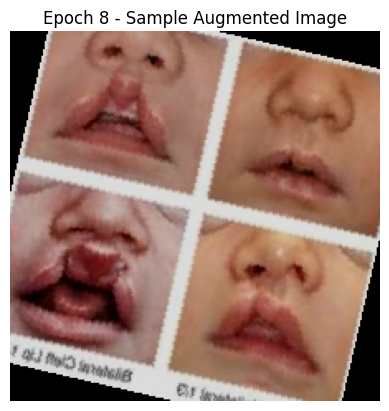

Batch 0 | Loss: 0.1112
Epoch Loss: 1.9627 | Accuracy: 96.90%

Epoch 9/10


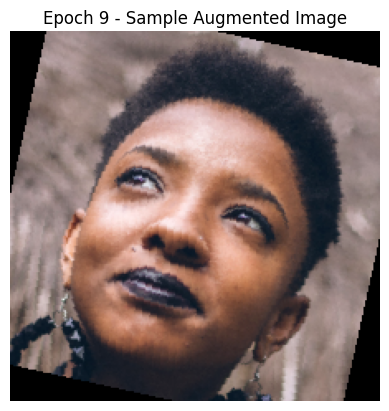

Batch 0 | Loss: 0.1871
Epoch Loss: 1.4301 | Accuracy: 97.24%

Epoch 10/10


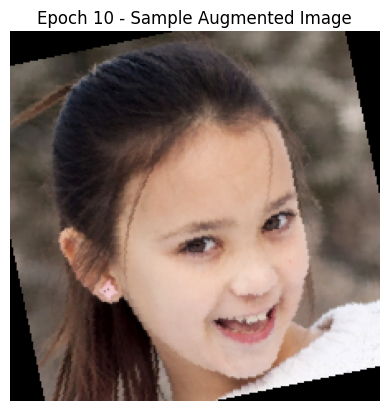

Batch 0 | Loss: 0.1993
Epoch Loss: 1.5739 | Accuracy: 96.90%


In [30]:
epochs = 10

for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    print(f"\nEpoch {epoch+1}/{epochs}")

    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # ---- SHOW IMAGE (only once per epoch) ----
        if i == 0:
            img = images[0].detach().cpu().permute(1, 2, 0)  # CHW → HWC

            plt.imshow(img)
            plt.title(f"Epoch {epoch+1} - Sample Augmented Image")
            plt.axis("off")
            plt.show()
        # ------------------------------------------

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        if i % 10 == 0:
            print(f"Batch {i} | Loss: {loss.item():.4f}")

    acc = 100 * correct / total
    print(f"Epoch Loss: {total_loss:.4f} | Accuracy: {acc:.2f}%")

In [31]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Validation Accuracy:", 100 * correct / total)

Validation Accuracy: 96.7741935483871


In [32]:
model.eval()

correct = 0
total = 0

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = 100 * correct / total

print("Test Accuracy:", test_acc)

Test Accuracy: 98.41269841269842


In [33]:
import torch

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().numpy())

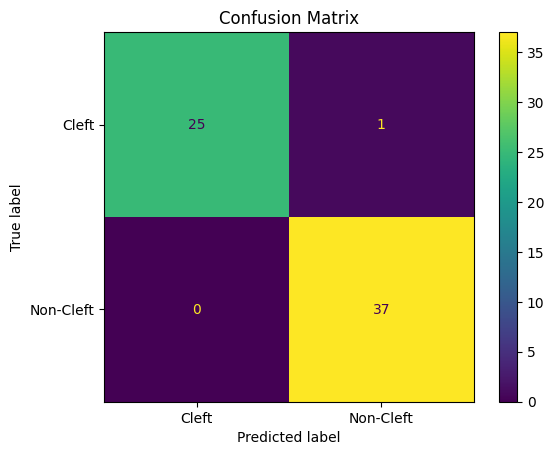

In [34]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["Cleft", "Non-Cleft"])

disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [35]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds,
                            target_names=["Cleft", "Non-Cleft"]))

              precision    recall  f1-score   support

       Cleft       1.00      0.96      0.98        26
   Non-Cleft       0.97      1.00      0.99        37

    accuracy                           0.98        63
   macro avg       0.99      0.98      0.98        63
weighted avg       0.98      0.98      0.98        63



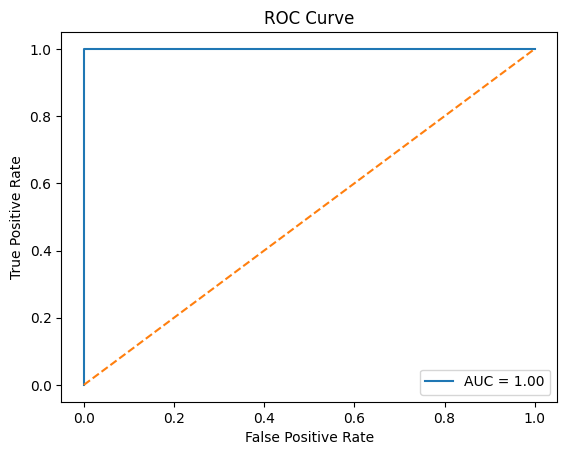

In [36]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [37]:
gradients = None
activations = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

target_layer = model.layer4[-1]

target_layer.register_forward_hook(forward_hook)
target_layer.register_full_backward_hook(backward_hook)

In [38]:
model.eval()

image, label = test_dataset[0]
input_tensor = image.unsqueeze(0).to(device)

output = model(input_tensor)
pred_class = output.argmax(dim=1)

model.zero_grad()
output[0, pred_class].backward()

In [39]:
print("Gradients is None:", gradients is None)
print("Activations is None:", activations is None)

Gradients is None: False
Activations is None: False


In [44]:
# Convert to numpy
grads = gradients.detach().cpu().numpy()[0]
acts = activations.detach().cpu().numpy()[0]

# Global average pooling (weights)
weights = np.mean(grads, axis=(1, 2))

# Weighted sum of feature maps
cam = np.zeros(acts.shape[1:], dtype=np.float32)

for i, w in enumerate(weights):
    cam += w * acts[i]

# ReLU
cam = np.maximum(cam, 0)

# Resize to input size
cam = cv2.resize(cam, (224, 224))

# Normalize
cam = cam - cam.min()
cam = cam / (cam.max() + 1e-8)

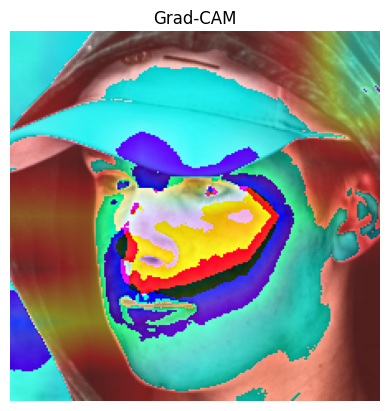

In [46]:
import cv2
import numpy as np

img = image.permute(1, 2, 0).cpu().numpy()

heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
overlay = heatmap * 0.4 + img * 255

plt.imshow(overlay.astype(np.uint8))
plt.title("Grad-CAM")
plt.axis("off")
plt.show()

In [48]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [49]:
import os

print(os.path.exists("/content/drive/MyDrive"))
print(os.listdir("/content/drive/MyDrive"))

True
['Software Analysis and Design', 'database', 'drawio files', 'word doc files', 'uk part time cv', 'pdf files', 'docs files', 'vechical detection', 'UML.drawio', 'Smart BCU Wellbeing App.gdoc', 'python', 'Details to give your employer – GOV.UK.pdf', 'Colab Notebooks', 'ai', '2025-09-25_Statement.pdf', 'Research Methodoliges', 'DineshPerumal_25102145', 'Msc Desertation', 'Untitled document.gdoc']


In [52]:
os.makedirs("/content/drive/MyDrive/Msc Desertation", exist_ok=True)

In [53]:
model_path = "/content/drive/MyDrive/Msc Desertation/resnet_cleft_model.pth"

torch.save(model.state_dict(), model_path)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/Msc Desertation/resnet_cleft_model.pth


In [54]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 2)

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()

print("Model loaded successfully")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


In [56]:
from PIL import Image
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

img_path = "/content/baby2.jpg"

image = Image.open(img_path).convert("RGB")
input_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    output = model(input_tensor)
    probs = torch.softmax(output, dim=1)
    pred = torch.argmax(probs, dim=1)

print("Prediction:", "Cleft" if pred.item() == 0 else "Non-Cleft")
print("Confidence:", probs.max().item())

Prediction: Non-Cleft
Confidence: 0.779813289642334
